C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!
Dataset created successfully!
Number of records: 20

Dataset Shape:
(20, 2)

Dataset Columns:
['instruction', 'response']

Missing Values:
instruction    0
response       0
dtype: int64

Duplicate Records:
0

Average Instruction Length: 7.95
Average Response Length: 17.95
Maximum Instruction Length: 11
Maximum Response Length: 24


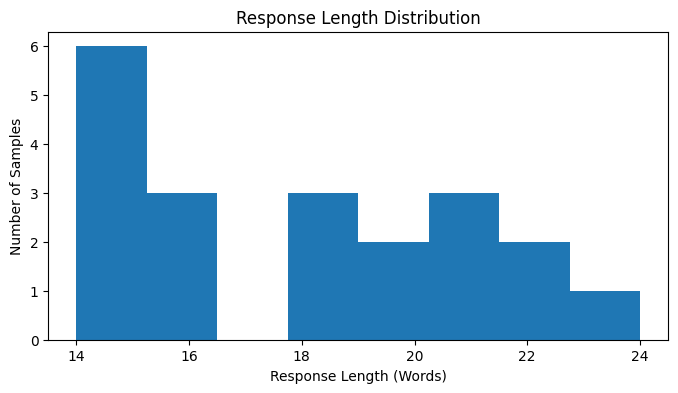

Example formatted training sample:

### Instruction:
How can I reset my password?

### Response:
To reset your password, open the login page and select the Forgot Password option. Follow the instructions sent to your registered email.

Final Dataset:
                                                text
0  ### Instruction:\nHow can I reset my password?...
1  ### Instruction:\nHow do I unlock my account?\...
2  ### Instruction:\nHow can I update my email ad...
3  ### Instruction:\nWhat should I do if I forget...
4  ### Instruction:\nHow can I contact technical ...

Hugging Face Dataset:
Dataset({
    features: ['text'],
    num_rows: 20
})

Training Samples: 16
Validation Samples: 4

Training Example:

### Instruction:
What should I do when my laptop is slow?

### Response:
Close unnecessary applications, restart your laptop, and check available disk space. Contact IT support if the issue continues.

PART 1 COMPLETED
Total Samples       : 20
Training Samples    : 16
Validation Samples  :

In [1]:
# ============================================================
# EFFICIENT FINE-TUNING USING LoRA & PEFT
# PROJECT: Efficient Fine-Tuning of a Small Language Model
# PART 1: DATASET CREATION, EDA & PREPROCESSING
# ============================================================


# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset

print("Libraries imported successfully!")


# ============================================================
# SECTION 2 : CREATE A SMALL ENTERPRISE DATASET
# ============================================================

# Small local dataset
# No external download required

data = [
    {
        "instruction": "How can I reset my password?",
        "response": "To reset your password, open the login page and select the Forgot Password option. Follow the instructions sent to your registered email."
    },
    {
        "instruction": "How do I unlock my account?",
        "response": "If your account is locked, contact the IT support team and verify your identity. The support team can unlock your account."
    },
    {
        "instruction": "How can I update my email address?",
        "response": "Open your account settings, select Profile Information, update your email address, and save the changes."
    },
    {
        "instruction": "What should I do if I forget my username?",
        "response": "Use the Forgot Username option on the login page. You may need to provide your registered email address to recover your username."
    },
    {
        "instruction": "How can I contact technical support?",
        "response": "You can contact technical support through the company's support portal or by raising a support ticket."
    },
    {
        "instruction": "How do I create a support ticket?",
        "response": "Open the support portal, select Create Ticket, enter the issue details, and submit the ticket."
    },
    {
        "instruction": "What should I do if the application is not working?",
        "response": "First restart the application and check your network connection. If the problem continues, create a support ticket with the error details."
    },
    {
        "instruction": "How can I check the status of my support ticket?",
        "response": "Log in to the support portal and open the My Tickets section to view the current status of your support ticket."
    },
    {
        "instruction": "How do I request access to an application?",
        "response": "Submit an access request through the company's access management portal. Your manager may need to approve the request."
    },
    {
        "instruction": "What should I do if I receive an access denied error?",
        "response": "Verify that you have the required permissions. If you still receive the error, raise a support ticket with the application name and error message."
    },
    {
        "instruction": "How can I change my phone number?",
        "response": "Open your profile settings, update the registered phone number, and complete the verification process."
    },
    {
        "instruction": "How do I report a security issue?",
        "response": "Report security issues immediately through the company's security incident reporting process and provide all available details."
    },
    {
        "instruction": "What should I do when my laptop is slow?",
        "response": "Close unnecessary applications, restart your laptop, and check available disk space. Contact IT support if the issue continues."
    },
    {
        "instruction": "How can I connect to the company VPN?",
        "response": "Open the approved VPN client, enter your corporate credentials, and connect to the company VPN."
    },
    {
        "instruction": "What should I do if the VPN is not connecting?",
        "response": "Check your internet connection, restart the VPN client, and try connecting again. Contact IT support if the issue persists."
    },
    {
        "instruction": "How can I request software installation?",
        "response": "Create a software installation request through the IT service portal and provide the required software name and business justification."
    },
    {
        "instruction": "How do I update my employee profile?",
        "response": "Open the employee portal, navigate to your profile, update the required information, and save the changes."
    },
    {
        "instruction": "What should I do if I cannot access the employee portal?",
        "response": "Check your network connection and verify your login credentials. If the issue continues, contact the IT support team."
    },
    {
        "instruction": "How can I request a new laptop?",
        "response": "Submit a hardware request through the IT service portal. The request may require manager approval."
    },
    {
        "instruction": "How do I check my application permissions?",
        "response": "Open the application's access management page and review the permissions assigned to your account."
    }
]


# ============================================================
# SECTION 3 : CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Number of records:", len(df))

df.head()


# ============================================================
# SECTION 4 : BASIC DATASET INFORMATION
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())


# ============================================================
# SECTION 5 : TEXT LENGTH ANALYSIS
# ============================================================

# Calculate number of words in instruction and response

df["instruction_length"] = df["instruction"].apply(
    lambda x: len(x.split())
)

df["response_length"] = df["response"].apply(
    lambda x: len(x.split())
)


print("\nAverage Instruction Length:",
      round(df["instruction_length"].mean(), 2))

print("Average Response Length:",
      round(df["response_length"].mean(), 2))

print("Maximum Instruction Length:",
      df["instruction_length"].max())

print("Maximum Response Length:",
      df["response_length"].max())


# ============================================================
# SECTION 6 : VISUALIZE TEXT LENGTH
# ============================================================

plt.figure(figsize=(8, 4))

plt.hist(
    df["response_length"],
    bins=8
)

plt.xlabel("Response Length (Words)")
plt.ylabel("Number of Samples")
plt.title("Response Length Distribution")

plt.show()


# ============================================================
# SECTION 7 : CREATE INSTRUCTION-FORMATTED TEXT
# ============================================================

# LoRA fine-tuning will train a causal language model.
# Therefore, instruction + response are combined into one text.

def create_prompt(row):

    return (
        "### Instruction:\n"
        + row["instruction"]
        + "\n\n"
        "### Response:\n"
        + row["response"]
    )


df["text"] = df.apply(create_prompt, axis=1)


# Display an example

print("Example formatted training sample:\n")
print(df["text"].iloc[0])


# ============================================================
# SECTION 8 : KEEP ONLY REQUIRED COLUMN
# ============================================================

df = df[["text"]]

print("\nFinal Dataset:")
print(df.head())


# ============================================================
# SECTION 9 : CONVERT TO HUGGING FACE DATASET
# ============================================================

dataset = Dataset.from_pandas(df)

print("\nHugging Face Dataset:")
print(dataset)


# ============================================================
# SECTION 10 : TRAIN / VALIDATION SPLIT
# ============================================================

dataset_split = dataset.train_test_split(
    test_size=0.2,
    seed=42
)

train_dataset = dataset_split["train"]
validation_dataset = dataset_split["test"]


print("\nTraining Samples:",
      len(train_dataset))

print("Validation Samples:",
      len(validation_dataset))


# ============================================================
# SECTION 11 : DISPLAY TRAINING SAMPLE
# ============================================================

print("\nTraining Example:\n")

print(train_dataset[0]["text"])


# ============================================================
# SECTION 12 : FINAL DATASET SUMMARY
# ============================================================

print("\n============================================================")
print("PART 1 COMPLETED")
print("============================================================")

print("Total Samples       :", len(dataset))
print("Training Samples    :", len(train_dataset))
print("Validation Samples  :", len(validation_dataset))

print("\nDataset is ready for tokenization and LoRA fine-tuning.")

In [2]:
# ============================================================
# EFFICIENT FINE-TUNING USING LoRA & PEFT
# PROJECT : Efficient Fine-Tuning of a Small Language Model
# PART 2 : MODEL + TOKENIZER + LoRA / PEFT SETUP
# ============================================================


# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model
)

print("Libraries imported successfully!")


# ============================================================
# SECTION 2 : CHECK DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# SECTION 3 : DEFINE SMALL LANGUAGE MODEL
# ============================================================

MODEL_NAME = "distilgpt2"

print("Model:", MODEL_NAME)


# ============================================================
# SECTION 4 : LOAD TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

# GPT-style models do not have a separate padding token.
# We use EOS token as padding token.

tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded successfully!")

print("Vocabulary Size:",
      len(tokenizer))


# ============================================================
# SECTION 5 : TOKENIZE TRAINING DATA
# ============================================================

MAX_LENGTH = 128


def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )


train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

validation_tokenized = validation_dataset.map(
    tokenize_function,
    batched=True
)


print("Training dataset tokenized!")
print("Validation dataset tokenized!")


# ============================================================
# SECTION 6 : CREATE LABELS FOR CAUSAL LANGUAGE MODEL
# ============================================================

def add_labels(example):

    example["labels"] = example["input_ids"].copy()

    return example


train_tokenized = train_tokenized.map(
    add_labels
)

validation_tokenized = validation_tokenized.map(
    add_labels
)


# ============================================================
# SECTION 7 : REMOVE ORIGINAL TEXT COLUMN
# ============================================================

train_tokenized = train_tokenized.remove_columns(
    ["text"]
)

validation_tokenized = validation_tokenized.remove_columns(
    ["text"]
)


# ============================================================
# SECTION 8 : SET PYTORCH FORMAT
# ============================================================

train_tokenized.set_format(
    type="torch"
)

validation_tokenized.set_format(
    type="torch"
)


print("\nTokenized Training Dataset:")
print(train_tokenized)

print("\nTokenized Validation Dataset:")
print(validation_tokenized)


# ============================================================
# SECTION 9 : LOAD PRETRAINED LANGUAGE MODEL
# ============================================================

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

print("\nBase model loaded successfully!")


# ============================================================
# SECTION 10 : CONFIGURE LoRA
# ============================================================

lora_config = LoraConfig(

    # Task performed by the model
    task_type=TaskType.CAUSAL_LM,

    # LoRA rank
    r=4,

    # LoRA scaling factor
    lora_alpha=8,

    # Dropout for LoRA layers
    lora_dropout=0.05,

    # GPT-2 attention projection module
    target_modules=["c_attn"],

    # No bias training
    bias="none"
)


print("\nLoRA configuration created!")


# ============================================================
# SECTION 11 : APPLY LoRA TO MODEL
# ============================================================

model = get_peft_model(
    model,
    lora_config
)


# ============================================================
# SECTION 12 : DISPLAY TRAINABLE PARAMETERS
# ============================================================

print("\n============================================================")
print("MODEL PARAMETER ANALYSIS")
print("============================================================")

model.print_trainable_parameters()


# ============================================================
# SECTION 13 : MOVE MODEL TO DEVICE
# ============================================================

model = model.to(device)

print("\nModel moved to:", device)


# ============================================================
# SECTION 14 : CHECK ONE TOKENIZED SAMPLE
# ============================================================

sample = train_tokenized[0]

print("\n============================================================")
print("TOKENIZED SAMPLE")
print("============================================================")

print("Input IDs:")
print(sample["input_ids"][:20])

print("\nAttention Mask:")
print(sample["attention_mask"][:20])

print("\nLabels:")
print(sample["labels"][:20])


# ============================================================
# SECTION 15 : FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("PART 2 COMPLETED")
print("============================================================")

print("Model              :", MODEL_NAME)
print("Maximum Length     :", MAX_LENGTH)
print("LoRA Rank (r)      :", 4)
print("LoRA Alpha         :", 8)
print("LoRA Dropout       :", 0.05)
print("Target Module      :", "c_attn")
print("Device             :", device)

print("\nThe base model is now ready for efficient fine-tuning.")

Libraries imported successfully!
Device: cpu
Model: distilgpt2


Tokenizer loaded successfully!
Vocabulary Size: 50257


Map: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 800.17 examples/s]


Training dataset tokenized!
Validation dataset tokenized!


Map: 100%|███████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 685.96 examples/s]



Tokenized Training Dataset:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 16
})

Tokenized Validation Dataset:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4
})


Loading weights: 100%|███████████████████████████████████████████████████████████████| 76/76 [00:00<00:00, 1049.78it/s]



Base model loaded successfully!

LoRA configuration created!

MODEL PARAMETER ANALYSIS
trainable params: 73,728 || all params: 81,986,304 || trainable%: 0.0899

Model moved to: cpu

TOKENIZED SAMPLE
Input IDs:
tensor([21017, 46486,    25,   198,  2061,   815,   314,   466,   618,   616,
        13224,   318,  3105,    30,   198,   198, 21017, 18261,    25,   198])

Attention Mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Labels:
tensor([21017, 46486,    25,   198,  2061,   815,   314,   466,   618,   616,
        13224,   318,  3105,    30,   198,   198, 21017, 18261,    25,   198])

PART 2 COMPLETED
Model              : distilgpt2
Maximum Length     : 128
LoRA Rank (r)      : 4
LoRA Alpha         : 8
LoRA Dropout       : 0.05
Target Module      : c_attn
Device             : cpu

The base model is now ready for efficient fine-tuning.


C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\Lib\site-packages\peft\tuners\lora\layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [4]:
# ============================================================
# EFFICIENT FINE-TUNING USING LoRA & PEFT
# PROJECT : Efficient Fine-Tuning of a Small Language Model
# PART 3 : LoRA FINE-TUNING & EVALUATION
# ============================================================


# ============================================================
# SECTION 1 : IMPORT TRAINING LIBRARIES
# ============================================================

from transformers import (
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

import os
import torch


print("Training libraries imported successfully!")


# ============================================================
# SECTION 2 : DEFINE TRAINING CONFIGURATION
# ============================================================

OUTPUT_DIR = "./lora_training_output"

FINAL_MODEL_PATH = "./lora_adapter"

EPOCHS = 1

BATCH_SIZE = 1

LEARNING_RATE = 2e-4

GRADIENT_ACCUMULATION_STEPS = 4


print("Training Configuration")
print("----------------------")
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Gradient Accumulation:", GRADIENT_ACCUMULATION_STEPS)


# ============================================================
# SECTION 3 : CREATE DATA COLLATOR
# ============================================================

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("\nData collator created successfully!")


# ============================================================
# SECTION 4 : DEFINE TRAINING ARGUMENTS
# ============================================================

training_args = TrainingArguments(

    # Where intermediate training files are stored
    output_dir=OUTPUT_DIR,

    # Number of epochs
    num_train_epochs=EPOCHS,

    # CPU-friendly batch size
    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=BATCH_SIZE,

    # Gradient accumulation reduces memory usage
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    # Learning rate
    learning_rate=LEARNING_RATE,

    # Logging
    logging_steps=1,

    # Evaluate after each epoch
    eval_strategy="epoch",

    # Save after each epoch
    save_strategy="epoch",

    # Keep only one checkpoint
    save_total_limit=1,

    # CPU workers
    dataloader_num_workers=0,

    # Disable mixed precision because we are using CPU
    fp16=False,

    # Disable BF16
    bf16=False,

    # Do not remove columns automatically
    remove_unused_columns=False,

    # Report results nowhere
    report_to="none"
)


print("Training arguments created successfully!")


# ============================================================
# SECTION 5 : CREATE TRAINER
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=validation_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("\nTrainer created successfully!")

# ============================================================
# SECTION 6 : DISPLAY TRAINABLE PARAMETERS
# ============================================================

print("\n============================================================")
print("TRAINABLE PARAMETERS BEFORE TRAINING")
print("============================================================")

model.print_trainable_parameters()


# ============================================================
# SECTION 7 : START LoRA FINE-TUNING
# ============================================================

print("\n============================================================")
print("STARTING LoRA FINE-TUNING")
print("============================================================")

train_result = trainer.train()


# ============================================================
# SECTION 8 : TRAINING RESULTS
# ============================================================

print("\n============================================================")
print("TRAINING COMPLETED")
print("============================================================")

print("Training Metrics:")

print(
    "Training Loss:",
    train_result.training_loss
)

print(
    "Training Runtime:",
    train_result.metrics.get(
        "train_runtime",
        "N/A"
    ),
    "seconds"
)


# ============================================================
# SECTION 9 : EVALUATE MODEL
# ============================================================

print("\n============================================================")
print("MODEL EVALUATION")
print("============================================================")

evaluation_results = trainer.evaluate()


print("\nEvaluation Results:")

for key, value in evaluation_results.items():

    print(
        key,
        ":",
        value
    )


# ============================================================
# SECTION 10 : SAVE LoRA ADAPTER
# ============================================================

print("\n============================================================")
print("SAVING LoRA ADAPTER")
print("============================================================")

# Save only the PEFT/LoRA adapter
model.save_pretrained(
    FINAL_MODEL_PATH
)

# Save tokenizer
tokenizer.save_pretrained(
    FINAL_MODEL_PATH
)


print("LoRA adapter saved successfully!")

print(
    "Saved Location:",
    FINAL_MODEL_PATH
)


# ============================================================
# SECTION 11 : CHECK SAVED FILES
# ============================================================

print("\nSaved Files:")

if os.path.exists(FINAL_MODEL_PATH):

    for file_name in os.listdir(FINAL_MODEL_PATH):

        print("-", file_name)


# ============================================================
# SECTION 12 : FINAL TRAINABLE PARAMETER CHECK
# ============================================================

print("\n============================================================")
print("FINAL MODEL PARAMETER ANALYSIS")
print("============================================================")

model.print_trainable_parameters()


# ============================================================
# SECTION 13 : PART 3 SUMMARY
# ============================================================

print("\n============================================================")
print("PART 3 COMPLETED")
print("============================================================")

print("Model Training     : Completed")
print("Technique           : LoRA")
print("Framework           : PEFT")
print("Epochs              :", EPOCHS)
print("Batch Size          :", BATCH_SIZE)
print("Learning Rate       :", LEARNING_RATE)
print("Adapter Location    :", FINAL_MODEL_PATH)

print("\nThe LoRA adapter is ready for inference.")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Training libraries imported successfully!
Training Configuration
----------------------
Epochs: 1
Batch Size: 1
Learning Rate: 0.0002
Gradient Accumulation: 4

Data collator created successfully!
Training arguments created successfully!

Trainer created successfully!

TRAINABLE PARAMETERS BEFORE TRAINING
trainable params: 73,728 || all params: 81,986,304 || trainable%: 0.0899

STARTING LoRA FINE-TUNING


C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.651045,3.887556



TRAINING COMPLETED
Training Metrics:
Training Loss: 3.907558500766754
Training Runtime: 15.5918 seconds

MODEL EVALUATION


C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch
3.651045,3.887556,1



Evaluation Results:
eval_loss : 3.8875560760498047

SAVING LoRA ADAPTER
LoRA adapter saved successfully!
Saved Location: ./lora_adapter

Saved Files:
- adapter_config.json
- adapter_model.safetensors
- README.md
- tokenizer.json
- tokenizer_config.json

FINAL MODEL PARAMETER ANALYSIS
trainable params: 73,728 || all params: 81,986,304 || trainable%: 0.0899

PART 3 COMPLETED
Model Training     : Completed
Technique           : LoRA
Framework           : PEFT
Epochs              : 1
Batch Size          : 1
Learning Rate       : 0.0002
Adapter Location    : ./lora_adapter

The LoRA adapter is ready for inference.


In [5]:
# ============================================================
# EFFICIENT FINE-TUNING USING LoRA & PEFT
# PROJECT : Efficient Fine-Tuning of a Small Language Model
# PART 4 : LoRA LOADING, INFERENCE & MODEL COMPARISON
# ============================================================


# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from peft import (
    PeftModel
)


print("Libraries imported successfully!")


# ============================================================
# SECTION 2 : DEFINE MODEL PATHS
# ============================================================

BASE_MODEL_NAME = "distilgpt2"

LORA_MODEL_PATH = "./lora_adapter"


print("Base Model :", BASE_MODEL_NAME)
print("LoRA Path  :", LORA_MODEL_PATH)


# ============================================================
# SECTION 3 : LOAD BASE TOKENIZER
# ============================================================

inference_tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_NAME
)

inference_tokenizer.pad_token = (
    inference_tokenizer.eos_token
)


print("\nTokenizer loaded successfully!")


# ============================================================
# SECTION 4 : LOAD BASE MODEL
# ============================================================

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME
)

base_model = base_model.to(device)

base_model.eval()


print("Base model loaded successfully!")


# ============================================================
# SECTION 5 : LOAD LoRA ADAPTER
# ============================================================

lora_model = PeftModel.from_pretrained(
    base_model,
    LORA_MODEL_PATH
)

lora_model = lora_model.to(device)

lora_model.eval()


print("LoRA adapter loaded successfully!")


# ============================================================
# SECTION 6 : CREATE GENERATION FUNCTION
# ============================================================

def generate_response(model, question):

    prompt = (
        "### Instruction:\n"
        + question
        + "\n\n"
        "### Response:\n"
    )

    inputs = inference_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            pad_token_id=inference_tokenizer.eos_token_id
        )

    generated_text = inference_tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return generated_text


# ============================================================
# SECTION 7 : TEST QUESTIONS
# ============================================================

test_questions = [

    "How can I reset my password?",

    "What should I do if my VPN is not connecting?",

    "How can I create a support ticket?",

    "How can I request software installation?"

]


# ============================================================
# SECTION 8 : GENERATE LoRA MODEL RESPONSES
# ============================================================

print("\n============================================================")
print("LoRA MODEL RESPONSES")
print("============================================================")


for question in test_questions:

    print("\nQuestion:")
    print(question)

    response = generate_response(
        lora_model,
        question
    )

    print("\nModel Response:")
    print(response)

    print("\n" + "-" * 60)


# ============================================================
# SECTION 9 : COMPARE BASE MODEL AND LoRA MODEL
# ============================================================

print("\n============================================================")
print("BASE MODEL vs LoRA MODEL")
print("============================================================")


comparison_question = (
    "How can I reset my password?"
)


print("\nQuestion:")
print(comparison_question)


print("\n---------------- BASE MODEL ----------------")

base_response = generate_response(
    base_model,
    comparison_question
)

print(base_response)


print("\n---------------- LoRA MODEL ----------------")

lora_response = generate_response(
    lora_model,
    comparison_question
)

print(lora_response)


# ============================================================
# SECTION 10 : CHECK LoRA TRAINABLE PARAMETERS
# ============================================================

print("\n============================================================")
print("LoRA PARAMETER ANALYSIS")
print("============================================================")

lora_model.print_trainable_parameters()


# ============================================================
# SECTION 11 : CALCULATE LoRA ADAPTER SIZE
# ============================================================

print("\n============================================================")
print("LoRA ADAPTER STORAGE SIZE")
print("============================================================")


total_size_bytes = 0

for root, dirs, files in os.walk(LORA_MODEL_PATH):

    for file_name in files:

        file_path = os.path.join(
            root,
            file_name
        )

        total_size_bytes += os.path.getsize(
            file_path
        )


total_size_mb = total_size_bytes / (
    1024 * 1024
)


print(
    "LoRA Adapter Size:",
    round(total_size_mb, 4),
    "MB"
)


# ============================================================
# SECTION 12 : LIST LoRA ADAPTER FILES
# ============================================================

print("\nLoRA Adapter Files:")

for root, dirs, files in os.walk(
    LORA_MODEL_PATH
):

    for file_name in files:

        print(
            "-",
            os.path.join(
                root,
                file_name
            )
        )


# ============================================================
# SECTION 13 : FINAL PROJECT SUMMARY
# ============================================================

print("\n============================================================")
print("PROJECT COMPLETED")
print("============================================================")

print("""
Project:
Efficient Fine-Tuning of a Small Language Model

Technique:
LoRA + PEFT

Base Model:
DistilGPT2

Dataset:
Small Enterprise Support Dataset

Fine-Tuning:
Parameter-Efficient Fine-Tuning

Training:
CPU-Friendly

Saved Model:
LoRA Adapter

Inference:
Successfully Loaded LoRA Adapter
""")


# ============================================================
# SECTION 14 : KEY LEARNING
# ============================================================

print("\n============================================================")
print("KEY LEARNING")
print("============================================================")

print("""
Full Fine-Tuning:
-----------------
Updates the entire pretrained model.

LoRA Fine-Tuning:
-----------------
Freezes the pretrained model and trains
small low-rank adapter matrices.

Advantages:
-----------
1. Fewer trainable parameters
2. Lower memory requirement
3. Faster fine-tuning
4. Smaller adapter files
5. Easy adapter deployment
6. Multiple task-specific adapters
   can use the same base model
""")


print("\n============================================================")
print("PART 4 COMPLETED SUCCESSFULLY")
print("============================================================")

Libraries imported successfully!
Base Model : distilgpt2
LoRA Path  : ./lora_adapter

Tokenizer loaded successfully!


Loading weights: 100%|███████████████████████████████████████████████████████████████| 76/76 [00:00<00:00, 5343.42it/s]


Base model loaded successfully!
LoRA adapter loaded successfully!

LoRA MODEL RESPONSES

Question:
How can I reset my password?

Model Response:
### Instruction:
How can I reset my password?

### Response:
I have a password reset. I have a password reset. I have a password reset. I have a password reset. I have a password reset. I have a password reset. I have a password reset. I have a password reset. I have

------------------------------------------------------------

Question:
What should I do if my VPN is not connecting?

Model Response:
### Instruction:
What should I do if my VPN is not connecting?

### Response:
I have a VPN that is not connected to my VPN. I have a VPN that is not connected to my VPN. I have a VPN that is not connected to my VPN. I have a VPN that is not connected to my VPN. I have

------------------------------------------------------------

Question:
How can I create a support ticket?

Model Response:
### Instruction:
How can I create a support ticket?

### 